In [30]:
# One-time install of libraries not in default Colab
!pip install -q torch pytorch-lightning xlrd

Rows: 29,184
Range: 1940-01-01 to 2024-12-31
Discharge: mean=6.98, max=154.00 m³/s


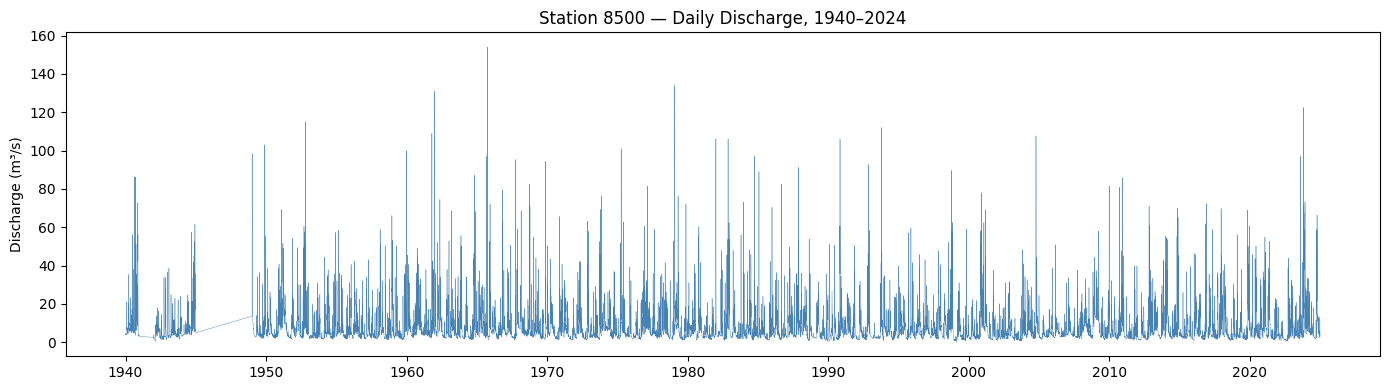

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Upload hid_8500_1940_2024.xls via Colab sidebar first
# If your file is .xls and xlrd struggles, save it as .xlsx in Excel/LibreOffice first
FILE = '/content/sample_data/hid_8500_1940_2024.xlsx'

df = pd.read_excel(FILE, sheet_name='hid_arhiv', skiprows=1, header=None)
df.columns = ['date', 'level_cm', 'Q_m3s', 'T_C', 'sed_kgs', 'sed_gm3']
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y', errors='coerce')
df = df.dropna(subset=['date', 'Q_m3s']).sort_values('date').reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Discharge: mean={df['Q_m3s'].mean():.2f}, max={df['Q_m3s'].max():.2f} m³/s")

# Plot the full record to see what we're working with
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['Q_m3s'], lw=0.3, color='steelblue')
ax.set_ylabel('Discharge (m³/s)')
ax.set_title('Station 8500 — Daily Discharge, 1940–2024')
plt.tight_layout(); plt.show()

In [33]:
# Drop sediment columns BEFORE doing anything else — they're for Project 2, not this one
df = df.drop(columns=['sed_kgs', 'sed_gm3'], errors='ignore')

# Feature engineering on the full discharge record
df['log_Q'] = np.log1p(df['Q_m3s'])
df['doy'] = df['date'].dt.dayofyear
df['doy_sin'] = np.sin(2 * np.pi * df['doy'] / 365.25)
df['doy_cos'] = np.cos(2 * np.pi * df['doy'] / 365.25)
df['month'] = df['date'].dt.month

# Fill T_C and level_cm with seasonal climatology where missing
for col in ['T_C', 'level_cm']:
    seasonal = df.groupby('doy')[col].transform('mean')
    df[col] = df[col].fillna(seasonal)
    df[col] = df[col].fillna(df[col].mean())

# Lagged features — yesterday and a week ago help short-horizon forecasts
for lag in [1, 2, 3, 7, 14, 30]:
    df[f'Q_lag{lag}'] = df['log_Q'].shift(lag)

# Rolling stats — captures wetness state
df['Q_roll7'] = df['log_Q'].rolling(7, min_periods=1).mean()
df['Q_roll30'] = df['log_Q'].rolling(30, min_periods=1).mean()

# Antecedent wetness proxies — discharge dynamics as a stand-in for precipitation
df['Q_diff1'] = df['log_Q'].diff(1)        # rate of change yesterday
df['Q_diff3'] = df['log_Q'].diff(3)        # 3-day rate of change
df['Q_max7'] = df['log_Q'].rolling(7, min_periods=1).max()   # recent peak indicator
df['Q_min7'] = df['log_Q'].rolling(7, min_periods=1).min()
df['Q_range7'] = df['Q_max7'] - df['Q_min7']  # flashiness of the last week

# Now dropna — only the first 30 rows should disappear (because of Q_lag30)
n_before = len(df)
df = df.dropna().reset_index(drop=True)
n_after = len(df)

print(f"After feature engineering: {n_after:,} rows (dropped {n_before - n_after} — should be ~30)")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(df[['date', 'Q_m3s', 'log_Q', 'doy_sin', 'Q_lag1', 'Q_roll7', 'Q_diff1', 'Q_range7']].head())

After feature engineering: 29,154 rows (dropped 30 — should be ~30)
Date range: 1940-01-31 to 2024-12-31
        date  Q_m3s     log_Q   doy_sin    Q_lag1   Q_roll7   Q_diff1  \
0 1940-01-31   3.88  1.585145  0.508356  1.585145  1.596058  0.000000   
1 1940-02-01   3.88  1.585145  0.523094  1.585145  1.590602  0.000000   
2 1940-02-02   4.49  1.702928  0.537677  1.585145  1.601971  0.117783   
3 1940-02-03   4.28  1.663926  0.552101  1.702928  1.613226 -0.039002   
4 1940-02-04  21.12  3.096482  0.566362  1.663926  1.829131  1.432556   

   Q_range7  
0  0.038196  
1  0.038196  
2  0.117783  
3  0.117783  
4  1.511337  


In [34]:
# Time-series split — NEVER shuffle. Always split by time.
# Pre-2010: training. 2010-2017: validation. 2018-2024: hold-out test.
train = df[df['date'] < '2010-01-01'].copy()
val   = df[(df['date'] >= '2010-01-01') & (df['date'] < '2018-01-01')].copy()
test  = df[df['date'] >= '2018-01-01'].copy()

print(f"Train: {len(train):,} days ({train['date'].min().year}-{train['date'].max().year})")
print(f"Val:   {len(val):,} days  ({val['date'].min().year}-{val['date'].max().year})")
print(f"Test:  {len(test):,} days  ({test['date'].min().year}-{test['date'].max().year})")

FEATURES = ['log_Q', 'T_C', 'level_cm', 'doy_sin', 'doy_cos',
            'Q_lag1', 'Q_lag2', 'Q_lag3', 'Q_lag7', 'Q_lag14', 'Q_lag30',
            'Q_roll7', 'Q_roll30',
            'Q_diff1', 'Q_diff3', 'Q_max7', 'Q_min7', 'Q_range7']

TARGET = 'log_Q'  # we predict log-discharge then invert later

# Normalise using TRAINING stats only — this is critical
means = train[FEATURES].mean()
stds = train[FEATURES].std()

for split in [train, val, test]:
    for col in FEATURES:
        split[col] = (split[col] - means[col]) / stds[col]

Train: 23,712 days (1940-2009)
Val:   2,885 days  (2010-2017)
Test:  2,557 days  (2018-2024)


In [35]:
import torch
from torch.utils.data import Dataset, DataLoader

SEQ_LEN = 30   # 30 days of history feeds the model
HORIZON = 7    # forecast 7 days ahead

def make_sequences(df_split, features, target, seq_len, horizon):
    """Slice the dataframe into overlapping (X, y) sequences."""
    X, y = [], []
    feat_arr = df_split[features].values
    targ_arr = df_split[target].values
    for i in range(len(df_split) - seq_len - horizon + 1):
        X.append(feat_arr[i:i+seq_len])
        y.append(targ_arr[i+seq_len:i+seq_len+horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_sequences(train, FEATURES, TARGET, SEQ_LEN, HORIZON)
X_val,   y_val   = make_sequences(val,   FEATURES, TARGET, SEQ_LEN, HORIZON)
X_test,  y_test  = make_sequences(test,  FEATURES, TARGET, SEQ_LEN, HORIZON)

print(f"X_train shape: {X_train.shape}  (samples, seq_len, features)")
print(f"y_train shape: {y_train.shape}  (samples, horizon)")

class FlowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X); self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(FlowDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader   = DataLoader(FlowDataset(X_val,   y_val),   batch_size=256)
test_loader  = DataLoader(FlowDataset(X_test,  y_test),  batch_size=256)

X_train shape: (23676, 30, 18)  (samples, seq_len, features)
y_train shape: (23676, 7)  (samples, horizon)


In [36]:
import torch.nn as nn

class StreamflowLSTM(nn.Module):
    def __init__(self, n_features, hidden=64, n_layers=2, horizon=7, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, n_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, horizon)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])  # use last timestep's hidden state

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = StreamflowLSTM(n_features=len(FEATURES), horizon=HORIZON).to(device)
print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Training on: cuda
StreamflowLSTM(
  (lstm): LSTM(18, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=7, bias=True)
  )
)
Trainable params: 59,399


Trainable params: 225,287
Epoch  1/60  train=1.9814  val=2.0369  lr=0.00100
Epoch  2/60  train=1.7341  val=2.0231  lr=0.00100
Epoch  3/60  train=1.7068  val=2.0177  lr=0.00100
Epoch  4/60  train=1.6765  val=2.0017  lr=0.00100
Epoch  5/60  train=1.6435  val=2.0046  lr=0.00100
Epoch  6/60  train=1.6011  val=2.0761  lr=0.00100
Epoch  7/60  train=1.5280  val=2.0651  lr=0.00100
Epoch  8/60  train=1.4549  val=2.1082  lr=0.00100
Epoch  9/60  train=1.3510  val=2.1373  lr=0.00100
Epoch 10/60  train=1.2471  val=2.3194  lr=0.00050
Epoch 11/60  train=1.0661  val=2.4469  lr=0.00050
Epoch 12/60  train=0.9741  val=2.4914  lr=0.00050
Epoch 13/60  train=0.8981  val=2.6044  lr=0.00050
Epoch 14/60  train=0.8342  val=2.6633  lr=0.00050
Epoch 15/60  train=0.7704  val=2.6739  lr=0.00050
Epoch 16/60  train=0.7149  val=2.6888  lr=0.00025
Early stopping at epoch 16


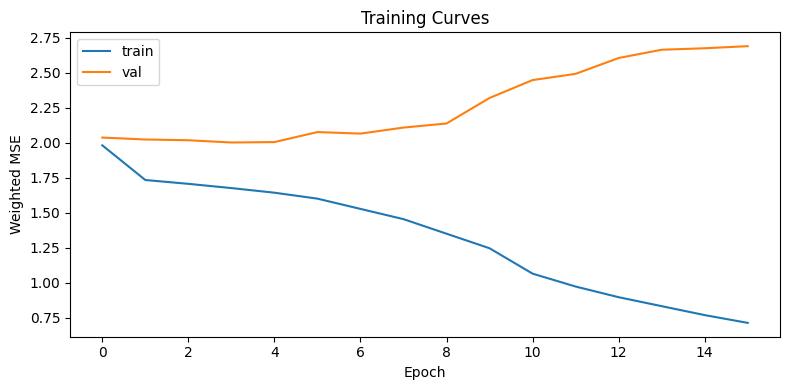

<All keys matched successfully>

In [37]:
import torch.nn as nn
import torch.nn.functional as F

# Rebuild model with more capacity
class StreamflowLSTM(nn.Module):
    def __init__(self, n_features, hidden=128, n_layers=2, horizon=7, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, n_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, horizon)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = StreamflowLSTM(n_features=len(FEATURES), hidden=128, horizon=HORIZON).to(device)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def weighted_mse(pred, target):
    """Gentler peak weighting — was overshooting recessions before."""
    w = 1.0 + 1.5 * torch.abs(target)   # was 3.0, now 1.5
    return ((pred - target) ** 2 * w).mean()

N_EPOCHS = 60
train_losses, val_losses = [], []
best_val = float('inf')
patience_counter = 0

for epoch in range(N_EPOCHS):
    model.train()
    tloss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = weighted_mse(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # stop gradient explosions
        optimizer.step()
        tloss += loss.item() * len(X)
    tloss /= len(train_loader.dataset)

    model.eval()
    vloss = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            vloss += weighted_mse(model(X), y).item() * len(X)
    vloss /= len(val_loader.dataset)

    scheduler.step(vloss)
    train_losses.append(tloss); val_losses.append(vloss)

    if vloss < best_val:
        best_val = vloss
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1:2d}/{N_EPOCHS}  train={tloss:.4f}  val={vloss:.4f}  lr={optimizer.param_groups[0]['lr']:.5f}")

    if patience_counter >= 12:
        print(f"Early stopping at epoch {epoch+1}")
        break

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='train'); ax.plot(val_losses, label='val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted MSE')
ax.legend(); ax.set_title('Training Curves')
plt.tight_layout(); plt.show()

model.load_state_dict(torch.load('best_model.pt'))

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()
preds = []
with torch.no_grad():
    for X, y in test_loader:
        preds.append(model(X.to(device)).cpu().numpy())
preds = np.concatenate(preds)

# De-normalise log_Q predictions and targets, then expm1 to get m³/s
y_test_real = np.expm1(y_test * stds[TARGET] + means[TARGET])
preds_real  = np.expm1(preds  * stds[TARGET] + means[TARGET])

# Persistence baseline: tomorrow = today's actual flow (use the raw test discharge)
raw_test_Q = test['Q_m3s'].values
persistence_pred = np.zeros_like(y_test_real)
for i in range(len(preds)):
    today_value = raw_test_Q[SEQ_LEN + i - 1]   # the day right before the forecast window
    persistence_pred[i, :] = today_value         # predict the same value for all 7 days

# Seasonal naive baseline: same day last year
seasonal_pred = np.zeros_like(y_test_real)
test_dates_all = test['date'].values
for i in range(len(preds)):
    for h in range(HORIZON):
        target_date = pd.Timestamp(test_dates_all[SEQ_LEN + i + h])
        last_year = target_date - pd.DateOffset(years=1)
        match = df[df['date'] == last_year]
        seasonal_pred[i, h] = match['Q_m3s'].values[0] if len(match) > 0 else raw_test_Q.mean()

def nse(obs, pred):
    return 1 - np.sum((obs - pred)**2) / np.sum((obs - obs.mean())**2)

print(f"{'Horizon':>8}  {'Model':<14}  {'MAE':>7}  {'RMSE':>7}  {'NSE':>6}")
print("-" * 55)
for h in range(HORIZON):
    obs = y_test_real[:, h]
    for name, pred in [('LSTM', preds_real[:, h]),
                       ('Persistence', persistence_pred[:, h]),
                       ('Seasonal naive', seasonal_pred[:, h])]:
        print(f"  Day +{h+1}  {name:<14}  "
              f"{mean_absolute_error(obs, pred):7.3f}  "
              f"{np.sqrt(mean_squared_error(obs, pred)):7.3f}  "
              f"{nse(obs, pred):6.3f}")
    print()

 Horizon  Model               MAE     RMSE     NSE
-------------------------------------------------------
  Day +1  LSTM              2.366    5.931   0.587
  Day +1  Persistence       2.226    6.220   0.546
  Day +1  Seasonal naive    7.513   13.045  -0.996

  Day +2  LSTM              3.389    7.219   0.389
  Day +2  Persistence       3.374    8.156   0.220
  Day +2  Seasonal naive    7.513   13.045  -0.996

  Day +3  LSTM              3.842    7.760   0.294
  Day +3  Persistence       3.952    9.016   0.047
  Day +3  Seasonal naive    7.514   13.045  -0.996

  Day +4  LSTM              4.115    8.050   0.237
  Day +4  Persistence       4.306    9.368  -0.034
  Day +4  Seasonal naive    7.506   13.039  -1.003

  Day +5  LSTM              4.275    8.232   0.201
  Day +5  Persistence       4.573    9.698  -0.108
  Day +5  Seasonal naive    7.500   13.034  -1.002

  Day +6  LSTM              4.385    8.439   0.161
  Day +6  Persistence       4.880   10.000  -0.179
  Day +6  Seasonal na

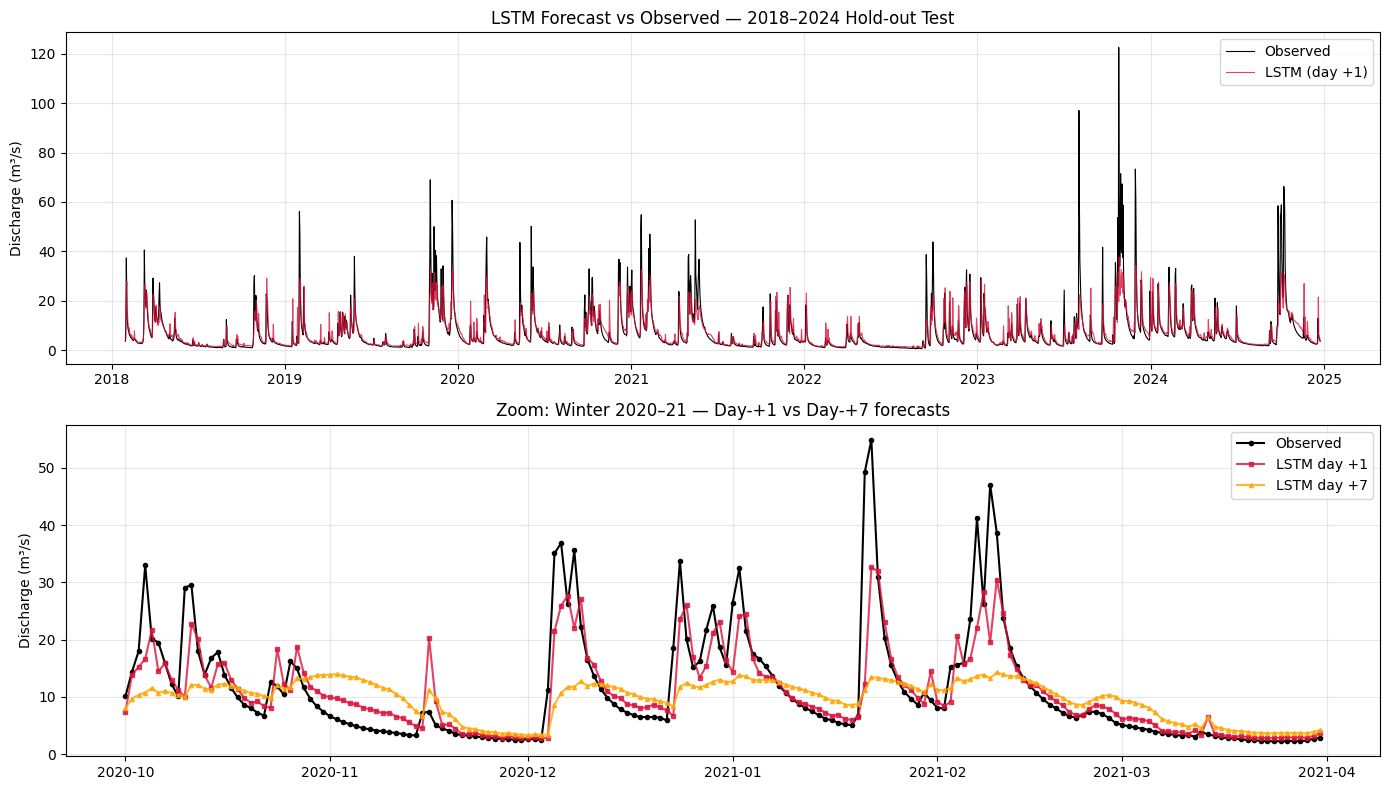

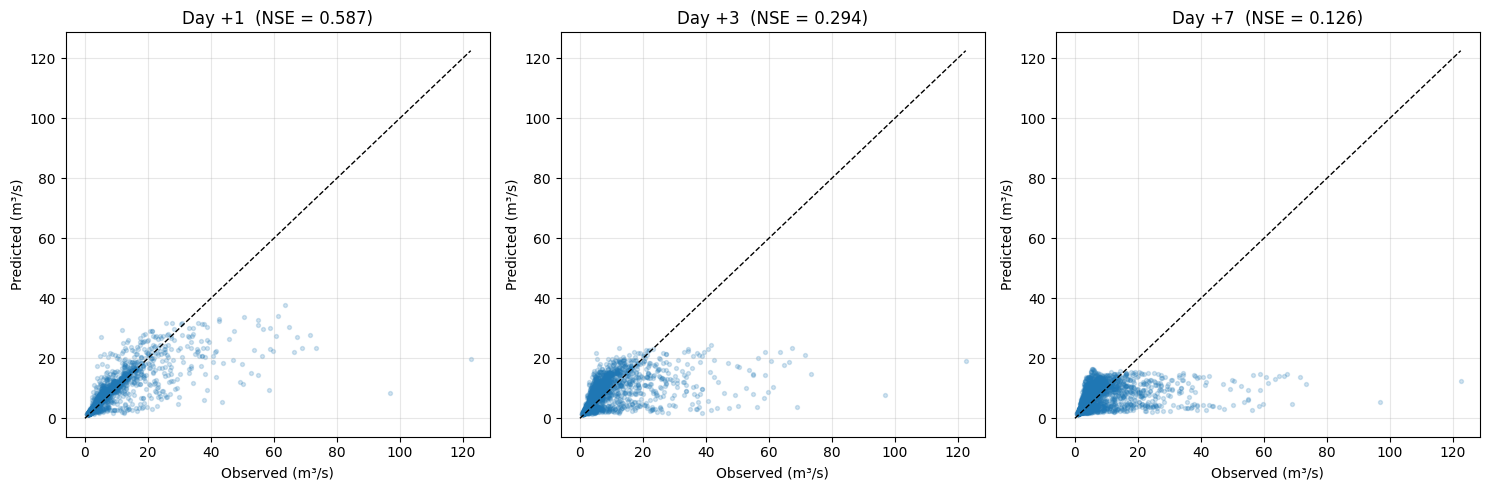

In [39]:
# Plot a year of day+1 predictions vs observations
test_dates = test['date'].values[SEQ_LEN-1 : SEQ_LEN-1+len(preds)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full test period
axes[0].plot(test_dates, y_test_real[:, 0], label='Observed', color='black', lw=0.8)
axes[0].plot(test_dates, preds_real[:, 0], label='LSTM (day +1)', color='crimson', lw=0.8, alpha=0.8)
axes[0].set_ylabel('Discharge (m³/s)')
axes[0].set_title('LSTM Forecast vs Observed — 2018–2024 Hold-out Test')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Zoom on a single high-flow event year
mask = (pd.to_datetime(test_dates) >= '2020-10-01') & (pd.to_datetime(test_dates) < '2021-04-01')
axes[1].plot(test_dates[mask], y_test_real[mask, 0], 'o-', label='Observed', color='black', ms=3)
axes[1].plot(test_dates[mask], preds_real[mask, 0], 's-', label='LSTM day +1', color='crimson', ms=3, alpha=0.8)
axes[1].plot(test_dates[mask], preds_real[mask, 6], '^-', label='LSTM day +7', color='orange', ms=3, alpha=0.8)
axes[1].set_ylabel('Discharge (m³/s)')
axes[1].set_title('Zoom: Winter 2020–21 — Day-+1 vs Day-+7 forecasts')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Scatter plot — predicted vs observed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, h in enumerate([0, 2, 6]):  # day +1, +3, +7
    obs = y_test_real[:, h]; pred = preds_real[:, h]
    axes[i].scatter(obs, pred, alpha=0.2, s=8)
    lim = max(obs.max(), pred.max())
    axes[i].plot([0, lim], [0, lim], 'k--', lw=1)
    axes[i].set_xlabel('Observed (m³/s)'); axes[i].set_ylabel('Predicted (m³/s)')
    axes[i].set_title(f'Day +{h+1}  (NSE = {nse(obs, pred):.3f})')
    axes[i].grid(alpha=0.3)
plt.tight_layout(); plt.show()